最终策略：
P(Retrieve | signal=0) = 0.3912
P(Retrieve | signal=1) = 0.9760
最近 50 个 episode 的平均 Reward = 0.6059
最近 50 个 episode 的经验 P(s_t = s_(t-1)) = 0.9003


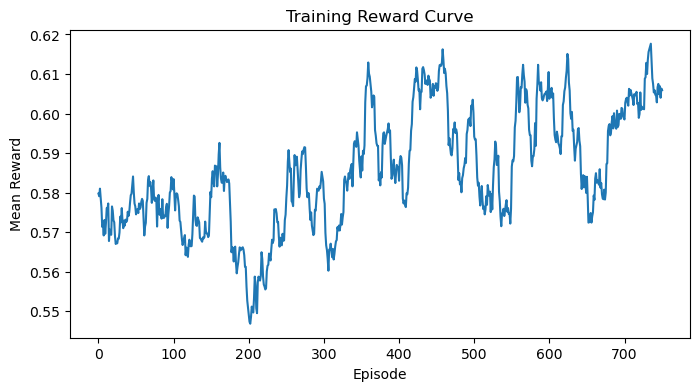

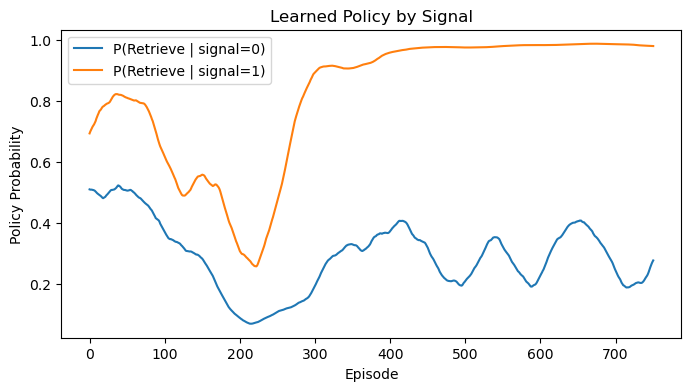

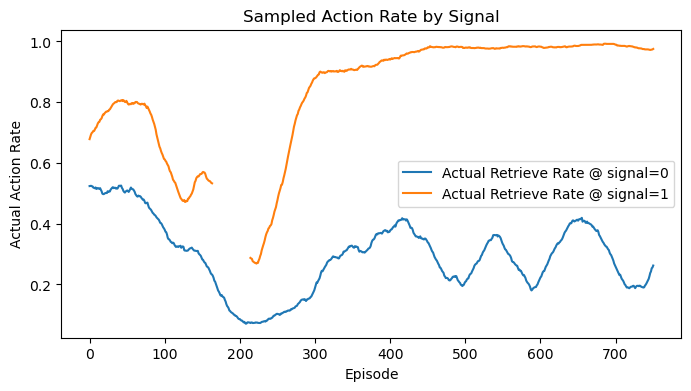

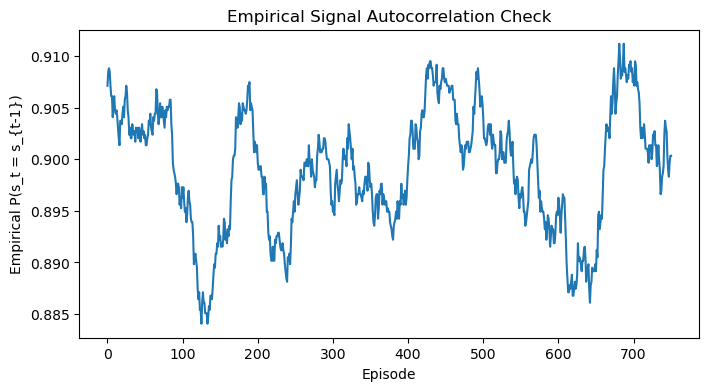

In [1]:
# =========================
# 0. 导入基础库
# =========================

# 导入 numpy
import numpy as np

# 导入 matplotlib 用来画训练曲线
import matplotlib.pyplot as plt


# =========================
# 1. 定义玩具环境
# =========================

class ToyMemoryEnv:
    """
    这个环境的最小设定如下：
    1) 环境里有一批固定物品，每个物品有一个固定隐藏价值。
    2) 每一轮先生成一个二元熟悉度信号 signal：
       - signal = 0 : 陌生 / novel
       - signal = 1 : 熟悉 / familiar
    3) signal 序列由一个二状态马尔可夫链生成，stay_prob 越大，自相关越高。
    4) 每轮展示两个物品。
    
    这里我做了一个非常关键的 MVP 解释：
    - signal = 0 时，优先从“未见过”的物品池里抽样 -> 更陌生
    - signal = 1 时，优先从“最近见过”的物品缓冲区里抽样 -> 更熟悉
    
    这样一来：
    - 熟悉信号更容易遇到可检索的旧物品
    - 陌生信号更容易遇到需要写入记忆的新物品
    """

    def __init__(
        self,
        n_items=200,
        value_levels=None,
        stay_prob=0.90,
        recent_buffer_size=4,
        seed=42
    ):
        # 保存随机数发生器，保证实验可复现
        self.rng = np.random.default_rng(seed)

        # 保存物品数量
        self.n_items = n_items

        # 保存马尔可夫链“保持原状态”的概率
        self.stay_prob = stay_prob

        # 保存“最近出现物品”的缓冲区长度
        self.recent_buffer_size = recent_buffer_size

        # 如果没有手动传入价值集合，就用题目给出的离散价值集合
        if value_levels is None:
            value_levels = [0.0, 0.25, 0.5, 0.75, 1.0]

        # 转成 numpy 数组，后面更方便
        self.value_levels = np.array(value_levels, dtype=float)

        # 计算未知物品的先验平均价值，后面 retrieve 时会用到
        self.prior_mean = float(np.mean(self.value_levels))

        # 为每个物品固定一个隐藏真实价值
        self.item_values = self.rng.choice(self.value_levels, size=self.n_items, replace=True)

        # 初始化回合状态
        self.reset()

    def reset(self):
        """
        每个 episode 开始时重置环境动态状态。
        注意：
        - 物品的真实价值不重置，它们在整个训练里保持固定。
        - 只重置“见过/没见过/最近见过/上一个信号”这些动态变量。
        """

        # seen_items 记录本 episode 中已经展示过的物品
        self.seen_items = set()

        # unseen_items 记录本 episode 中还没展示过的物品
        self.unseen_items = set(range(self.n_items))

        # recent_items 记录最近几次出现过的物品 ID
        self.recent_items = []

        # prev_signal 是马尔可夫链的上一时刻信号
        self.prev_signal = int(self.rng.integers(0, 2))

    def sample_signal(self):
        """
        用二状态马尔可夫链生成当前轮的熟悉度信号。
        规则：
        - 以 stay_prob 的概率保持上一状态
        - 以 (1 - stay_prob) 的概率翻转到另一个状态
        """

        # 根据 stay_prob 决定是否保持上一状态
        if self.rng.random() < self.stay_prob:
            signal = self.prev_signal
        else:
            signal = 1 - self.prev_signal

        # 更新上一状态
        self.prev_signal = signal

        # 返回当前信号
        return int(signal)

    def _sample_two_from_recent(self):
        """
        从 recent_items 中抽两个不同的物品。
        这里允许 recent_items 内部有重复，因为重复本身就代表“更熟悉”。
        """

        # 先抽第一个物品
        item_a = int(self.rng.choice(self.recent_items))

        # 再抽第二个物品
        item_b = int(self.rng.choice(self.recent_items))

        # 保证两个物品不同
        while item_b == item_a:
            item_b = int(self.rng.choice(self.recent_items))

        # 返回两个不同的物品
        return item_a, item_b

    def sample_items(self, signal):
        """
        根据当前信号，抽取本轮展示的两个物品。
        - signal = 1 时：优先从 recent_items 中抽 -> 熟悉
        - signal = 0 时：优先从 unseen_items 中抽 -> 陌生
        """

        # 如果当前是熟悉信号
        if signal == 1:
            # 若最近缓冲区里至少有两个不同物品，就从这里抽
            if len(set(self.recent_items)) >= 2:
                return self._sample_two_from_recent()

            # 否则，如果本 episode 已经见过至少两个物品，就从 seen_items 里抽
            elif len(self.seen_items) >= 2:
                pool = np.array(list(self.seen_items), dtype=int)
                item_a, item_b = self.rng.choice(pool, size=2, replace=False)
                return int(item_a), int(item_b)

            # 再不行，就从全体物品里兜底随机抽
            else:
                item_a, item_b = self.rng.choice(self.n_items, size=2, replace=False)
                return int(item_a), int(item_b)

        # 如果当前是陌生信号
        else:
            # 若还有至少两个未见物品，就优先从未见池中抽
            if len(self.unseen_items) >= 2:
                pool = np.array(list(self.unseen_items), dtype=int)
                item_a, item_b = self.rng.choice(pool, size=2, replace=False)
                return int(item_a), int(item_b)

            # 如果未见池不够了，就从全体物品里兜底随机抽
            else:
                item_a, item_b = self.rng.choice(self.n_items, size=2, replace=False)
                return int(item_a), int(item_b)

    def reveal(self, item_a, item_b):
        """
        在智能体做完选择后，环境揭晓这两个物品的真实价值。
        同时更新 seen / unseen / recent 三个动态结构。
        """

        # 读取两个物品的真实价值
        value_a = float(self.item_values[item_a])
        value_b = float(self.item_values[item_b])

        # 把这两个物品加入“已见集合”
        self.seen_items.add(item_a)
        self.seen_items.add(item_b)

        # 把这两个物品从“未见集合”里删除
        self.unseen_items.discard(item_a)
        self.unseen_items.discard(item_b)

        # 把这两个物品压入 recent buffer
        self.recent_items.extend([item_a, item_b])

        # 只保留最近 recent_buffer_size 个位置
        self.recent_items = self.recent_items[-self.recent_buffer_size:]

        # 返回这两个物品的真实价值
        return value_a, value_b


# =========================
# 2. 定义智能体
# =========================

class SimplePolicyAgent:
    """
    智能体只有两个动作：
    - ENCODE   = 0 : 写入
    - RETRIEVE = 1 : 读取
    
    策略只依赖当前信号 signal ∈ {0, 1}。
    也就是说，我们只学习两个参数：
    - theta[0] : 面对 signal=0 时选择 Retrieve 的倾向
    - theta[1] : 面对 signal=1 时选择 Retrieve 的倾向
    
    概率定义：
    P(Retrieve | signal=s) = sigmoid(theta[s])
    P(Encode   | signal=s) = 1 - sigmoid(theta[s])
    """

    # 定义动作常量：0 表示 Encode
    ENCODE = 0

    # 定义动作常量：1 表示 Retrieve
    RETRIEVE = 1

    def __init__(self, prior_mean=0.5, alpha=0.01, beta=0.05, seed=123):
        # 保存随机数发生器
        self.rng = np.random.default_rng(seed)

        # 保存未知物品的先验平均价值
        self.prior_mean = prior_mean

        # 策略学习率
        self.alpha = alpha

        # baseline 的更新速率
        self.beta = beta

        # theta[0], theta[1] 两个策略参数，初始为 0
        self.theta = np.zeros(2, dtype=float)

        # baseline[0], baseline[1] 两个状态基线，初始为 0
        self.baseline = np.zeros(2, dtype=float)

        # 记忆库：key 是 item_id，value 是真实价值
        self.memory = {}

    def reset_memory(self):
        """
        每个 episode 开始时清空记忆库。
        策略参数 theta 不清空，因为训练就是要跨 episode 保留它。
        """

        # 清空记忆字典
        self.memory = {}

    def retrieve_prob(self, signal):
        """
        计算在当前 signal 下选择 Retrieve 的概率。
        """
        # 为了数值稳定，先把 theta 裁剪一下
        clipped_theta = np.clip(self.theta[signal], -20.0, 20.0)

        # 计算 sigmoid
        p = 1.0 / (1.0 + np.exp(-clipped_theta))

        # 返回 Retrieve 概率
        return float(p)

    def sample_action(self, signal):
        """
        按照当前策略分布采样动作。
        返回：
        - action : 0 或 1
        - p      : 当时的 P(Retrieve | signal)
        """

        # 先算出 Retrieve 概率
        p = self.retrieve_prob(signal)

        # 按 Bernoulli 分布采样动作
        if self.rng.random() < p:
            action = self.RETRIEVE
        else:
            action = self.ENCODE

        # 返回动作和该时刻的 retrieve 概率
        return int(action), p

    def choose_by_retrieval(self, item_a, item_b):
        """
        当动作是 Retrieve 时，智能体会尝试读取这两个物品的价值估计。
        规则：
        - 若物品已在记忆库里，就用记忆中的真实价值
        - 若物品不在记忆库里，就用先验平均值 prior_mean
        - 选估计价值更高的那个
        - 若相等，则随机选一个
        """

        # 从记忆库里读取 item_a 的估计值；没有就用先验均值
        est_a = self.memory.get(item_a, self.prior_mean)

        # 从记忆库里读取 item_b 的估计值；没有就用先验均值
        est_b = self.memory.get(item_b, self.prior_mean)

        # 如果 a 的估计值更高，就选 a
        if est_a > est_b:
            return item_a

        # 如果 b 的估计值更高，就选 b
        elif est_b > est_a:
            return item_b

        # 如果相等，就随机选一个
        else:
            if self.rng.random() < 0.5:
                return item_a
            else:
                return item_b

    def encode_pair(self, item_a, value_a, item_b, value_b):
        """
        当动作是 Encode 时，把当前展示的两个物品及其真实价值写入记忆库。
        这里我采用“同时写入两个展示物品”的 MVP 设定。
        """

        # 写入第一个物品
        self.memory[item_a] = value_a

        # 写入第二个物品
        self.memory[item_b] = value_b

    def update_policy(self, signals, actions, probs, returns):
        """
        用 REINFORCE + baseline 更新策略。
        
        注意：
        这里用的是折扣回报 G_t，而不是单步 reward r_t。
        原因是：
        - Encode 的价值往往不是立刻出现
        - 它需要在后续 familiar 轮次里，靠 Retrieve 才体现出来
        - 所以必须做时间信用分配
        
        更新公式：
        theta_s <- theta_s + alpha * (G_t - baseline_s) * grad(log pi(a_t|s_t))
        
        对 Bernoulli 策略展开后：
        - 若 a_t = Retrieve :
            grad(log pi) = 1 - p
        - 若 a_t = Encode :
            grad(log pi) = -p
        """

        # 逐时间步更新
        for signal, action, p, G in zip(signals, actions, probs, returns):
            # 计算 advantage
            advantage = G - self.baseline[signal]

            # 如果动作是 Retrieve
            if action == self.RETRIEVE:
                grad_log_pi = 1.0 - p

            # 如果动作是 Encode
            else:
                grad_log_pi = -p

            # 按策略梯度更新 theta
            self.theta[signal] += self.alpha * advantage * grad_log_pi

            # 做一个裁剪，防止 theta 爆掉
            self.theta[signal] = np.clip(self.theta[signal], -8.0, 8.0)

            # 更新对应 signal 的 baseline
            self.baseline[signal] += self.beta * advantage


# =========================
# 3. 一些辅助函数
# =========================

def discounted_returns(rewards, gamma=0.98):
    """
    从后往前计算折扣回报：
    G_t = r_t + gamma * r_{t+1} + gamma^2 * r_{t+2} + ...
    """

    # 预先开一个同长度数组
    returns = np.zeros(len(rewards), dtype=float)

    # running 用来保存从后往前滚动的累计回报
    running = 0.0

    # 从最后一个时间步开始反向累计
    for t in range(len(rewards) - 1, -1, -1):
        running = rewards[t] + gamma * running
        returns[t] = running

    # 返回整条 return 序列
    return returns


def moving_average(x, window=50):
    """
    计算滑动平均，方便看平滑曲线。
    """

    # 转成 numpy 数组
    x = np.asarray(x, dtype=float)

    # 如果序列长度比窗口还短，就直接返回原序列
    if len(x) < window:
        return x

    # 构造均值卷积核
    kernel = np.ones(window, dtype=float) / window

    # 做一维卷积
    return np.convolve(x, kernel, mode="valid")


# =========================
# 4. 训练主循环
# =========================

def train_mvp(
    n_episodes=800,
    steps_per_episode=60,
    n_items=200,
    stay_prob=0.90,
    recent_buffer_size=4,
    gamma=0.98,
    alpha=0.01,
    beta=0.05,
    seed=7
):
    """
    训练入口。
    返回：
    - agent   : 训练好的智能体
    - history : 训练过程里的曲线数据
    """

    # 创建环境
    env = ToyMemoryEnv(
        n_items=n_items,
        stay_prob=stay_prob,
        recent_buffer_size=recent_buffer_size,
        seed=seed
    )

    # 创建智能体
    agent = SimplePolicyAgent(
        prior_mean=env.prior_mean,
        alpha=alpha,
        beta=beta,
        seed=seed + 1
    )

    # 记录每个 episode 的平均 reward
    episode_reward_history = []

    # 记录每个 episode 训练结束后的策略概率 P(Retrieve | signal=0)
    retrieve_prob_signal0_history = []

    # 记录每个 episode 训练结束后的策略概率 P(Retrieve | signal=1)
    retrieve_prob_signal1_history = []

    # 记录实际采样出来的 Retrieve 比例（按 signal 分开）
    actual_retrieve_rate_signal0_history = []
    actual_retrieve_rate_signal1_history = []

    # 记录经验上的“保持原状态概率”，用于验证高自相关
    stay_rate_history = []

    # 开始训练多个 episode
    for episode in range(n_episodes):
        # 每个 episode 都重置环境动态状态
        env.reset()

        # 每个 episode 都清空智能体记忆库
        agent.reset_memory()

        # 下面这些列表用来存本 episode 的轨迹
        signals = []
        actions = []
        probs = []
        rewards = []

        # 跑一个 episode 的时间步
        for step in range(steps_per_episode):
            # 先采样当前轮的熟悉度信号
            signal = env.sample_signal()

            # 再根据当前信号抽本轮的两个物品
            item_a, item_b = env.sample_items(signal)

            # 智能体根据当前 signal 采样动作
            action, p_retrieve = agent.sample_action(signal)

            # 如果动作是 Retrieve
            if action == agent.RETRIEVE:
                # 就根据记忆估计来做二选一
                chosen_item = agent.choose_by_retrieval(item_a, item_b)

            # 如果动作是 Encode
            else:
                # 按题意，这里只能随机猜一个
                if agent.rng.random() < 0.5:
                    chosen_item = item_a
                else:
                    chosen_item = item_b

            # 当前轮 reward = 被选中物品的真实价值
            reward = float(env.item_values[chosen_item])

            # 环境揭晓当前展示的两个物品的真实价值
            value_a, value_b = env.reveal(item_a, item_b)

            # 只有当动作是 Encode 时，才把信息写入记忆库
            if action == agent.ENCODE:
                agent.encode_pair(item_a, value_a, item_b, value_b)

            # 把本时间步轨迹存起来
            signals.append(signal)
            actions.append(action)
            probs.append(p_retrieve)
            rewards.append(reward)

        # 用整个 episode 的 reward 计算折扣回报
        returns = discounted_returns(rewards, gamma=gamma)

        # 用本 episode 的完整轨迹更新策略
        agent.update_policy(signals, actions, probs, returns)

        # 转成 numpy，后面统计更方便
        signals_np = np.array(signals, dtype=int)
        actions_np = np.array(actions, dtype=int)
        rewards_np = np.array(rewards, dtype=float)

        # 记录本 episode 的平均 reward
        episode_reward_history.append(float(np.mean(rewards_np)))

        # 记录当前策略下两个 signal 对应的 Retrieve 概率
        retrieve_prob_signal0_history.append(agent.retrieve_prob(0))
        retrieve_prob_signal1_history.append(agent.retrieve_prob(1))

        # 统计 signal=0 时实际采取 Retrieve 的比例
        if np.any(signals_np == 0):
            rate0 = float(np.mean(actions_np[signals_np == 0] == agent.RETRIEVE))
        else:
            rate0 = np.nan

        # 统计 signal=1 时实际采取 Retrieve 的比例
        if np.any(signals_np == 1):
            rate1 = float(np.mean(actions_np[signals_np == 1] == agent.RETRIEVE))
        else:
            rate1 = np.nan

        # 记录两种信号下的实际动作比例
        actual_retrieve_rate_signal0_history.append(rate0)
        actual_retrieve_rate_signal1_history.append(rate1)

        # 统计本 episode 里信号保持不变的比例，作为高自相关的经验检查
        if len(signals_np) >= 2:
            stay_rate = float(np.mean(signals_np[1:] == signals_np[:-1]))
        else:
            stay_rate = np.nan

        # 记录经验 stay rate
        stay_rate_history.append(stay_rate)

    # 整理输出历史
    history = {
        "episode_reward": np.array(episode_reward_history, dtype=float),
        "retrieve_prob_signal0": np.array(retrieve_prob_signal0_history, dtype=float),
        "retrieve_prob_signal1": np.array(retrieve_prob_signal1_history, dtype=float),
        "actual_retrieve_rate_signal0": np.array(actual_retrieve_rate_signal0_history, dtype=float),
        "actual_retrieve_rate_signal1": np.array(actual_retrieve_rate_signal1_history, dtype=float),
        "signal_stay_rate": np.array(stay_rate_history, dtype=float),
    }

    # 返回训练后的 agent 和历史曲线
    return agent, history


# =========================
# 5. 画图函数
# =========================

def plot_training_curves(history, smooth_window=50):
    """
    画三类曲线：
    1) 平均 reward
    2) 理论策略概率 P(Retrieve | signal=0/1)
    3) 实际采样到的 Retrieve 比例
    """

    # 取出 reward 曲线
    reward_curve = history["episode_reward"]

    # 取出策略概率曲线
    p0_curve = history["retrieve_prob_signal0"]
    p1_curve = history["retrieve_prob_signal1"]

    # 取出实际动作比例曲线
    a0_curve = history["actual_retrieve_rate_signal0"]
    a1_curve = history["actual_retrieve_rate_signal1"]

    # 取出 signal 的经验 stay rate
    stay_curve = history["signal_stay_rate"]

    # 第 1 张图：平均 reward
    plt.figure(figsize=(8, 4))
    plt.plot(moving_average(reward_curve, smooth_window))
    plt.xlabel("Episode")
    plt.ylabel("Mean Reward")
    plt.title("Training Reward Curve")
    plt.show()

    # 第 2 张图：策略概率曲线
    plt.figure(figsize=(8, 4))
    plt.plot(moving_average(p0_curve, smooth_window), label="P(Retrieve | signal=0)")
    plt.plot(moving_average(p1_curve, smooth_window), label="P(Retrieve | signal=1)")
    plt.xlabel("Episode")
    plt.ylabel("Policy Probability")
    plt.title("Learned Policy by Signal")
    plt.legend()
    plt.show()

    # 第 3 张图：实际动作比例曲线
    plt.figure(figsize=(8, 4))
    plt.plot(moving_average(a0_curve, smooth_window), label="Actual Retrieve Rate @ signal=0")
    plt.plot(moving_average(a1_curve, smooth_window), label="Actual Retrieve Rate @ signal=1")
    plt.xlabel("Episode")
    plt.ylabel("Actual Action Rate")
    plt.title("Sampled Action Rate by Signal")
    plt.legend()
    plt.show()

    # 第 4 张图：经验上的信号 stay rate
    plt.figure(figsize=(8, 4))
    plt.plot(moving_average(stay_curve, smooth_window))
    plt.xlabel("Episode")
    plt.ylabel("Empirical P(s_t = s_{t-1})")
    plt.title("Empirical Signal Autocorrelation Check")
    plt.show()


# =========================
# 6. 直接运行
# =========================

# 你后面要做“高/低自相关”对照实验时，
# 这里只需要改 stay_prob，例如：
# - 高自相关：0.90
# - 低自相关：0.55
agent, history = train_mvp(
    n_episodes=800,
    steps_per_episode=60,
    n_items=200,
    stay_prob=0.90,
    recent_buffer_size=4,
    gamma=0.98,
    alpha=0.01,
    beta=0.05,
    seed=7
)

# 打印最终学到的两种信号下的 Retrieve 概率
print("最终策略：")
print(f"P(Retrieve | signal=0) = {agent.retrieve_prob(0):.4f}")
print(f"P(Retrieve | signal=1) = {agent.retrieve_prob(1):.4f}")

# 打印最近 50 个 episode 的平均 reward
print(f"最近 50 个 episode 的平均 Reward = {np.mean(history['episode_reward'][-50:]):.4f}")

# 打印最近 50 个 episode 的经验 stay rate，检查是否接近设定的 0.90
print(f"最近 50 个 episode 的经验 P(s_t = s_(t-1)) = {np.mean(history['signal_stay_rate'][-50:]):.4f}")

# 画训练曲线
plot_training_curves(history, smooth_window=50)

最终策略（Unified GAE Actor-Critic）：
P(Retrieve | signal=0) = 0.1255
P(Retrieve | signal=1) = 0.7707
最终 gap = P1 - P0 = 0.6453
最近 50 个 episode 的平均 Reward = 0.6107
最近 50 个 episode 的经验 P(s_t = s_(t-1)) = 0.9003
最近 50 个 episode 的平均 Critic Loss = 31.071947
最近 50 个 episode 的平均 |Advantage| = 0.776102


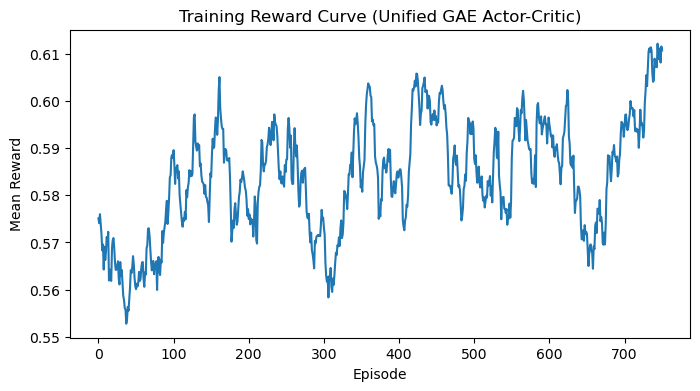

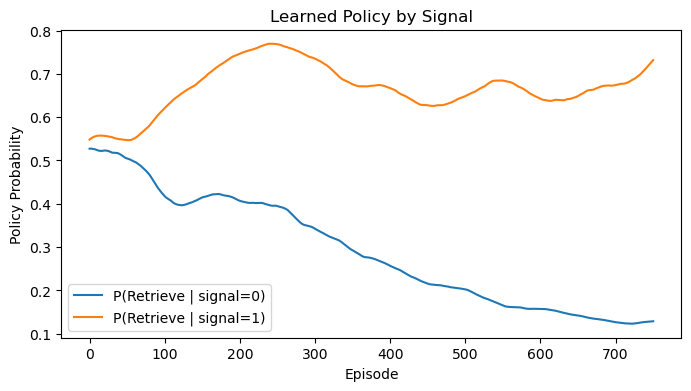

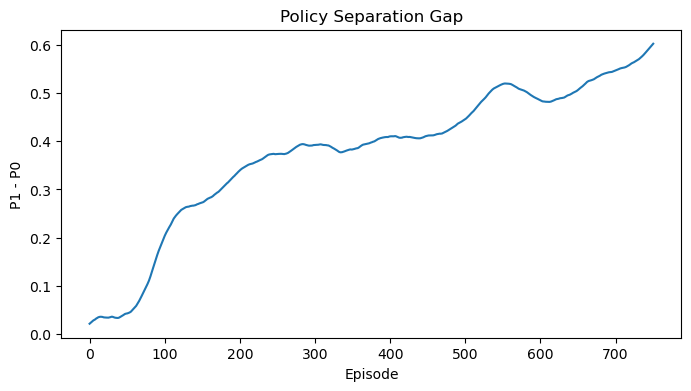

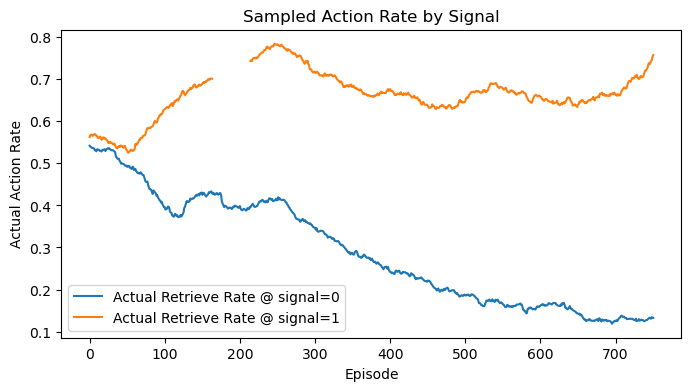

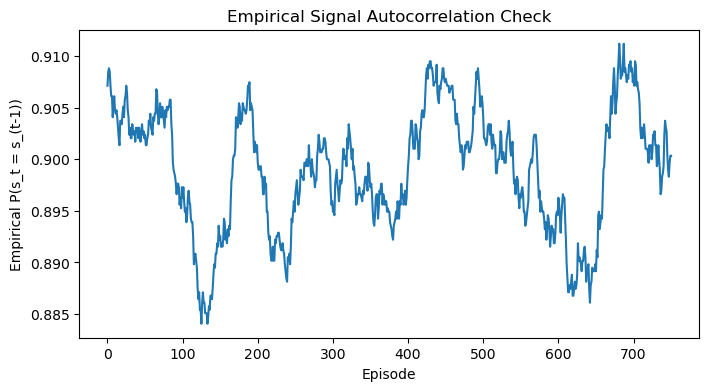

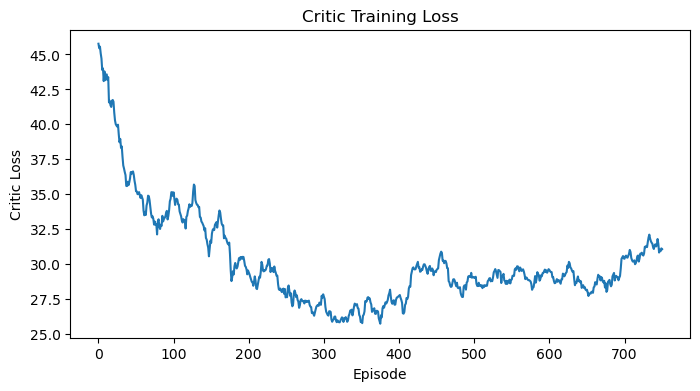

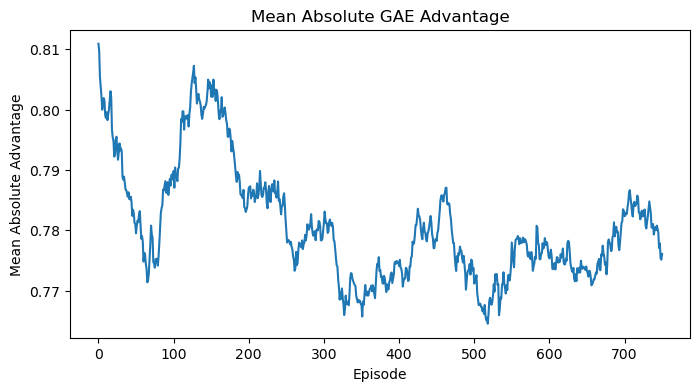

In [2]:
# ============================================================
# 统一 GAE Actor-Critic 版本（线性 Critic，不用神经网络）
# 使用前提：
# 请先运行你原 notebook 中定义 ToyMemoryEnv 的代码单元
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# 检查 ToyMemoryEnv 是否已存在
# -------------------------
try:
    ToyMemoryEnv
except NameError:
    raise NameError("请先运行原 notebook 中定义 ToyMemoryEnv 的代码单元。")


# =========================
# 1. 线性 Critic
# =========================
class LinearValueCritic:
    """
    线性值函数：
        V(x) = w · x + b

    输入特征共 4 维：
        1) signal
        2) recent_cov
        3) known_pair_count / 2
        4) recent_diversity
    """

    def __init__(self, input_dim=4, lr=0.01, seed=123):
        self.rng = np.random.default_rng(seed)
        self.lr = lr

        self.w = self.rng.normal(0.0, 0.05, size=input_dim)
        self.b = 0.0

    def predict_one(self, x):
        return float(np.dot(self.w, x) + self.b)

    def predict_batch(self, X):
        return X @ self.w + self.b

    def train_batch(self, X, targets):
        """
        一次 batch 的 MSE 更新：
            loss = mean( (V(x)-target)^2 )
        """
        targets = np.asarray(targets, dtype=float)
        preds = self.predict_batch(X)

        err = preds - targets
        loss = float(np.mean(err ** 2))

        N = X.shape[0]
        grad_w = (2.0 / N) * (X.T @ err)
        grad_b = (2.0 / N) * np.sum(err)

        # 轻微裁剪，避免训练太抖
        grad_w = np.clip(grad_w, -1.0, 1.0)
        grad_b = float(np.clip(grad_b, -1.0, 1.0))

        self.w -= self.lr * grad_w
        self.b -= self.lr * grad_b

        return loss


# =========================
# 2. 统一 GAE Actor-Critic Agent
# =========================
class SimplePolicyAgentGAE:
    """
    Actor 保持原来的极简形式：
        P(Retrieve | signal=s) = sigmoid(theta[s])

    训练时统一使用：
        - 线性 critic
        - GAE advantage
    """

    ENCODE = 0
    RETRIEVE = 1

    def __init__(
        self,
        prior_mean=0.5,
        actor_lr=0.01,
        critic_lr=0.01,
        seed=123
    ):
        self.rng = np.random.default_rng(seed)
        self.prior_mean = prior_mean

        # Actor 仍然只有两个参数
        self.theta = np.zeros(2, dtype=float)
        self.actor_lr = actor_lr

        # 记忆库
        self.memory = {}

        # 线性 Critic
        self.critic = LinearValueCritic(
            input_dim=4,
            lr=critic_lr,
            seed=seed + 99
        )

    def reset_memory(self):
        self.memory = {}

    def retrieve_prob(self, signal):
        z = np.clip(self.theta[signal], -20.0, 20.0)
        return float(1.0 / (1.0 + np.exp(-z)))

    def sample_action(self, signal):
        p = self.retrieve_prob(signal)
        if self.rng.random() < p:
            action = self.RETRIEVE
        else:
            action = self.ENCODE
        return int(action), p

    def choose_by_retrieval(self, item_a, item_b):
        est_a = self.memory.get(item_a, self.prior_mean)
        est_b = self.memory.get(item_b, self.prior_mean)

        if est_a > est_b:
            return item_a
        elif est_b > est_a:
            return item_b
        else:
            return item_a if self.rng.random() < 0.5 else item_b

    def encode_pair(self, item_a, value_a, item_b, value_b):
        self.memory[item_a] = value_a
        self.memory[item_b] = value_b

    def update_actor(self, signals, actions, probs, advantages):
        """
        用 GAE advantage 更新 actor
        """
        for signal, action, p, adv in zip(signals, actions, probs, advantages):
            if action == self.RETRIEVE:
                grad_log_pi = 1.0 - p
            else:
                grad_log_pi = -p

            self.theta[signal] += self.actor_lr * float(adv) * grad_log_pi
            self.theta[signal] = np.clip(self.theta[signal], -8.0, 8.0)


# =========================
# 3. 辅助特征函数
# =========================
def recent_coverage(agent, env):
    """
    recent_cov:
    recent buffer 中有多少比例已经在 memory 里
    """
    uniq = list(set(env.recent_items))
    if len(uniq) == 0:
        return 0.0

    hits = sum(1 for x in uniq if x in agent.memory)
    return hits / len(uniq)


def recent_diversity(env):
    """
    recent_diversity:
    recent buffer 中不同 item 的比例
    越高表示越混，越低表示越纯
    """
    if len(env.recent_items) == 0:
        return 0.0

    return len(set(env.recent_items)) / len(env.recent_items)


def build_state_features(signal, env, agent, item_a, item_b):
    """
    critic 的输入特征：
        1) signal
        2) recent_cov
        3) known_pair_count / 2
        4) recent_diversity
    """
    known_pair_count = int(item_a in agent.memory) + int(item_b in agent.memory)

    x = np.array([
        float(signal),
        float(recent_coverage(agent, env)),
        float(known_pair_count / 2.0),
        float(recent_diversity(env)),
    ], dtype=float)

    return x


# =========================
# 4. GAE 计算函数
# =========================
def compute_gae(rewards, values, gamma=0.98, lam=0.95):
    """
    输入：
        rewards: shape [T]
        values:  shape [T+1]
            注意这里 values 最后一个位置是 terminal state value，通常设 0

    输出：
        advantages: shape [T]
        value_targets: shape [T]
            用于训练 critic，通常 = advantages + values[:-1]
    """
    rewards = np.asarray(rewards, dtype=float)
    values = np.asarray(values, dtype=float)

    T = len(rewards)
    advantages = np.zeros(T, dtype=float)

    gae = 0.0
    for t in range(T - 1, -1, -1):
        delta = rewards[t] + gamma * values[t + 1] - values[t]
        gae = delta + gamma * lam * gae
        advantages[t] = gae

    value_targets = advantages + values[:-1]
    return advantages, value_targets


def moving_average(x, window=50):
    x = np.asarray(x, dtype=float)
    if len(x) < window:
        return x
    kernel = np.ones(window, dtype=float) / window
    return np.convolve(x, kernel, mode="valid")


# =========================
# 5. 统一 GAE 训练主循环
# =========================
def train_mvp_gae_linear(
    n_episodes=800,
    steps_per_episode=60,
    n_items=200,
    stay_prob=0.90,
    recent_buffer_size=4,
    gamma=0.98,
    lam=0.95,
    actor_lr=0.01,
    critic_lr=0.01,
    critic_train_iters=1,
    normalize_advantages=True,
    seed=7
):
    """
    统一算法：
        - 两种 signal 都使用同一个 GAE Actor-Critic
        - actor: 两参数 sigmoid policy
        - critic: 线性函数
        - advantage: 用 GAE 计算
    """

    env = ToyMemoryEnv(
        n_items=n_items,
        stay_prob=stay_prob,
        recent_buffer_size=recent_buffer_size,
        seed=seed
    )

    agent = SimplePolicyAgentGAE(
        prior_mean=env.prior_mean,
        actor_lr=actor_lr,
        critic_lr=critic_lr,
        seed=seed + 1
    )

    # 历史记录
    episode_reward_history = []
    retrieve_prob_signal0_history = []
    retrieve_prob_signal1_history = []
    actual_retrieve_rate_signal0_history = []
    actual_retrieve_rate_signal1_history = []
    stay_rate_history = []
    critic_loss_history = []
    mean_abs_advantage_history = []
    gap_history = []

    for episode in range(n_episodes):
        env.reset()
        agent.reset_memory()

        signals = []
        actions = []
        probs = []
        rewards = []
        features = []

        # ========== 跑一个 episode ==========
        for step in range(steps_per_episode):
            signal = env.sample_signal()
            item_a, item_b = env.sample_items(signal)

            # 动作前构造状态特征
            x_t = build_state_features(signal, env, agent, item_a, item_b)

            action, p_retrieve = agent.sample_action(signal)

            if action == agent.RETRIEVE:
                chosen_item = agent.choose_by_retrieval(item_a, item_b)
            else:
                chosen_item = item_a if agent.rng.random() < 0.5 else item_b

            reward = float(env.item_values[chosen_item])

            value_a, value_b = env.reveal(item_a, item_b)

            if action == agent.ENCODE:
                agent.encode_pair(item_a, value_a, item_b, value_b)

            signals.append(signal)
            actions.append(action)
            probs.append(p_retrieve)
            rewards.append(reward)
            features.append(x_t)

        # ========== episode 结束后统一更新 ==========
        signals_np = np.asarray(signals, dtype=int)
        actions_np = np.asarray(actions, dtype=int)
        probs_np = np.asarray(probs, dtype=float)
        rewards_np = np.asarray(rewards, dtype=float)
        X = np.asarray(features, dtype=float)

        # critic 预测当前各状态值
        values_now = agent.critic.predict_batch(X)

        # terminal state value = 0
        values_all = np.zeros(len(values_now) + 1, dtype=float)
        values_all[:-1] = values_now
        values_all[-1] = 0.0

        # GAE advantage
        advantages, value_targets = compute_gae(
            rewards=rewards_np,
            values=values_all,
            gamma=gamma,
            lam=lam
        )

        # 可选：标准化 advantage，降低训练抖动
        if normalize_advantages:
            adv_mean = np.mean(advantages)
            adv_std = np.std(advantages)
            advantages = (advantages - adv_mean) / (adv_std + 1e-8)

        # 先更新 critic
        critic_loss = np.nan
        for _ in range(critic_train_iters):
            critic_loss = agent.critic.train_batch(X, value_targets)

        # 再更新 actor
        agent.update_actor(
            signals=signals_np,
            actions=actions_np,
            probs=probs_np,
            advantages=advantages
        )

        # ========== 记录 history ==========
        episode_reward_history.append(float(np.mean(rewards_np)))
        retrieve_prob_signal0_history.append(agent.retrieve_prob(0))
        retrieve_prob_signal1_history.append(agent.retrieve_prob(1))

        if np.any(signals_np == 0):
            rate0 = float(np.mean(actions_np[signals_np == 0] == agent.RETRIEVE))
        else:
            rate0 = np.nan

        if np.any(signals_np == 1):
            rate1 = float(np.mean(actions_np[signals_np == 1] == agent.RETRIEVE))
        else:
            rate1 = np.nan

        actual_retrieve_rate_signal0_history.append(rate0)
        actual_retrieve_rate_signal1_history.append(rate1)

        if len(signals_np) >= 2:
            stay_rate = float(np.mean(signals_np[1:] == signals_np[:-1]))
        else:
            stay_rate = np.nan

        stay_rate_history.append(stay_rate)
        critic_loss_history.append(float(critic_loss))
        mean_abs_advantage_history.append(float(np.mean(np.abs(advantages))))
        gap_history.append(float(agent.retrieve_prob(1) - agent.retrieve_prob(0)))

    history = {
        "episode_reward": np.array(episode_reward_history, dtype=float),
        "retrieve_prob_signal0": np.array(retrieve_prob_signal0_history, dtype=float),
        "retrieve_prob_signal1": np.array(retrieve_prob_signal1_history, dtype=float),
        "actual_retrieve_rate_signal0": np.array(actual_retrieve_rate_signal0_history, dtype=float),
        "actual_retrieve_rate_signal1": np.array(actual_retrieve_rate_signal1_history, dtype=float),
        "signal_stay_rate": np.array(stay_rate_history, dtype=float),
        "critic_loss": np.array(critic_loss_history, dtype=float),
        "mean_abs_advantage": np.array(mean_abs_advantage_history, dtype=float),
        "gap_p1_minus_p0": np.array(gap_history, dtype=float),
    }

    return agent, history


# =========================
# 6. 画图函数
# =========================
def plot_training_curves_gae_linear(history, smooth_window=50):
    reward_curve = history["episode_reward"]
    p0_curve = history["retrieve_prob_signal0"]
    p1_curve = history["retrieve_prob_signal1"]
    a0_curve = history["actual_retrieve_rate_signal0"]
    a1_curve = history["actual_retrieve_rate_signal1"]
    stay_curve = history["signal_stay_rate"]
    critic_loss_curve = history["critic_loss"]
    mean_abs_adv_curve = history["mean_abs_advantage"]
    gap_curve = history["gap_p1_minus_p0"]

    plt.figure(figsize=(8, 4))
    plt.plot(moving_average(reward_curve, smooth_window))
    plt.xlabel("Episode")
    plt.ylabel("Mean Reward")
    plt.title("Training Reward Curve (Unified GAE Actor-Critic)")
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(moving_average(p0_curve, smooth_window), label="P(Retrieve | signal=0)")
    plt.plot(moving_average(p1_curve, smooth_window), label="P(Retrieve | signal=1)")
    plt.xlabel("Episode")
    plt.ylabel("Policy Probability")
    plt.title("Learned Policy by Signal")
    plt.legend()
    plt.savefig('54Actor_Critic_GAE_Learned_Policy_by_Signal.png', dpi=300, bbox_inches='tight')
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(moving_average(gap_curve, smooth_window))
    plt.xlabel("Episode")
    plt.ylabel("P1 - P0")
    plt.title("Policy Separation Gap")
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(moving_average(a0_curve, smooth_window), label="Actual Retrieve Rate @ signal=0")
    plt.plot(moving_average(a1_curve, smooth_window), label="Actual Retrieve Rate @ signal=1")
    plt.xlabel("Episode")
    plt.ylabel("Actual Action Rate")
    plt.title("Sampled Action Rate by Signal")
    plt.legend()
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(moving_average(stay_curve, smooth_window))
    plt.xlabel("Episode")
    plt.ylabel("Empirical P(s_t = s_(t-1))")
    plt.title("Empirical Signal Autocorrelation Check")
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(moving_average(critic_loss_curve, smooth_window))
    plt.xlabel("Episode")
    plt.ylabel("Critic Loss")
    plt.title("Critic Training Loss")
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(moving_average(mean_abs_adv_curve, smooth_window))
    plt.xlabel("Episode")
    plt.ylabel("Mean Absolute Advantage")
    plt.title("Mean Absolute GAE Advantage")
    plt.show()


# =========================
# 7. 直接运行（贴近你原 notebook 风格）
# =========================
agent_gae, history_gae = train_mvp_gae_linear(
    n_episodes=800,
    steps_per_episode=60,
    n_items=200,
    stay_prob=0.90,
    recent_buffer_size=4,
    gamma=0.98,
    lam=0.95,                 # GAE 的 lambda，可调
    actor_lr=0.01,
    critic_lr=0.01,
    critic_train_iters=1,
    normalize_advantages=True,
    seed=7
)

print("最终策略（Unified GAE Actor-Critic）：")
print(f"P(Retrieve | signal=0) = {agent_gae.retrieve_prob(0):.4f}")
print(f"P(Retrieve | signal=1) = {agent_gae.retrieve_prob(1):.4f}")
print(f"最终 gap = P1 - P0 = {agent_gae.retrieve_prob(1) - agent_gae.retrieve_prob(0):.4f}")
print(f"最近 50 个 episode 的平均 Reward = {np.mean(history_gae['episode_reward'][-50:]):.4f}")
print(f"最近 50 个 episode 的经验 P(s_t = s_(t-1)) = {np.mean(history_gae['signal_stay_rate'][-50:]):.4f}")
print(f"最近 50 个 episode 的平均 Critic Loss = {np.mean(history_gae['critic_loss'][-50:]):.6f}")
print(f"最近 50 个 episode 的平均 |Advantage| = {np.mean(history_gae['mean_abs_advantage'][-50:]):.6f}")

plot_training_curves_gae_linear(history_gae, smooth_window=50)